# Libraries

In [1]:
from obj import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [2]:
# --- CONFIGURAÇÕES GERAIS ---
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (10,6)


# Beam dataset

Just one sample was select for the test.

In [3]:
file_path = r'final_df_tempo_limite.xlsx'
full_df = pd.read_excel(file_path)
df = full_df.head(1)
df

,b_w,h,f_ck,f_yk,m_rd,m_gk,m_qk,a_s,time
0,0.14,0.3,20000,500000,9.836582,6.323517,0.702613,0.000076,50.621397


# State Limit Function evaluation

### Simulation parameters

In [6]:
# Number of simulations
n_simul = 10

# Time lapse for the durability analysis (in years)
times = np.arange(0, 101, 1)

# Concrete cover (mm)
cob = 25

# Modulus of elasticity of steel (kPa)
e_s = 200E6

# Progression of carbonation (mm/year^0.5)
prog_y = 6

# Stochastic simulation

### Initialization Variables

In [5]:
results_bw = []
results_mr = []
results_ms = []
results_as = []   
results_g  = []     
t_without_cor  = []   

### Monte Carlo simulation

This algorithm performs a time-dependent simulation of the state limit function for the concrete beam deterioration problem, considering carbonation-induced corrosion.

In [8]:
for i, row in df.iterrows():
    # Beam parameters
    b_w = row['b_w']            
    h = row['h']                
    f_ck = row['f_ck']          
    f_yk = row['f_yk']                
    m_gk = row['m_gk']         
    m_qk = row['m_qk']          
    a_s_initial = 1.6E-4 # row['a_s']

    # Stochastic simulation   
    for j in range(n_simul):
        m_r_list = []             
        a_s_list = []               
        m_s_list = []               
        g_list = []                 

        # Sampling the random variables
        f_ck_sample = 20000     # np.random.normal(1.22 * f_ck, 0.12 * 1.22 * f_ck)
        f_yk_sample = 500E3     # np.random.normal(1.22 * f_yk, 0.05 * 1.22 * f_yk)
        m_gk_sample = 6.320     # np.random.normal(1.06 * m_gk, 0.12 * 1.06 * m_gk)
        relacao_d_h = 0.900     # np.random.uniform(0.8, 0.9)
        i_corr_20 = 0.431       # np.random.normal(loc=0.431, scale=0.259) 
        if i_corr_20 < 0:
            i_corr_20 = 1E-5
        else:
            i_corr_20 = i_corr_20

        # Loop through each time step (e.g., years)
        for k in times:
            # Sampling the stochastic random variables for each time step
            m_qk_sample = 1.381   # np.random.gumbel(0.21 * m_qk, 0.21 * 0.76 * m_qk)
            temp = 23.56          # np.random.uniform(20, 30)
            d_barras = 12.5/1000
            n_barras = a_s_initial / (np.pi * d_barras**2 / 4)
            y_carb = prog_y * k**0.5

            # Bending moment capacity calculation
            if y_carb > cob:
               t_dur = k - t_without_cor[-1]
               m_rd, c_f, d_novo, d = momento_resistente_com_corrosao_azad_algohi(d_barras, n_barras, f_ck_sample, f_yk_sample, e_s, b_w, h, relacao_d_h, i_corr_20, temp, k, t_without_cor[-1], gamma_c=1.00, gamma_s= 1.00)
                                                                                      
            else:
                t_without_cor.append(k)
                m_rd = momento_limite_armadura_simples(a_s_initial, b_w, h, relacao_d_h, f_ck_sample, f_yk_sample, e_s)

            # Armazenar os resultados para este passo de tempo
            m_r_list.append(m_rd)
            m_s_list.append(m_gk_sample + m_qk_sample)
            # a_s_list.append(a_s_degraded)
            g_list.append(m_rd - (m_gk_sample + m_qk_sample))

        # Resultados da simulação temporal completa
        results_mr.append(m_r_list)
        results_ms.append(m_s_list)
        results_as.append(a_s_list)
        results_g.append(g_list)
        h_aux = [h] * len(times)
        f_ck_aux = [f_ck_sample] * len(times)
        f_yk_aux = [f_yk_sample] * len(times)

In [9]:
df_out = pd.DataFrame(results_g).T
df_out.index = times

print(df_out)


             0          1          2          3          4          5  \
0    12.554462  12.554462  12.554462  12.554462  12.554462  12.554462   
1    12.554462  12.554462  12.554462  12.554462  12.554462  12.554462   
2    12.554462  12.554462  12.554462  12.554462  12.554462  12.554462   
3    12.554462  12.554462  12.554462  12.554462  12.554462  12.554462   
4    12.554462  12.554462  12.554462  12.554462  12.554462  12.554462   
..         ...        ...        ...        ...        ...        ...   
96    5.436249   5.436249   5.436249   5.436249   5.436249   5.436249   
97    5.377796   5.377796   5.377796   5.377796   5.377796   5.377796   
98    5.319956   5.319956   5.319956   5.319956   5.319956   5.319956   
99    5.262715   5.262715   5.262715   5.262715   5.262715   5.262715   
100   5.206056   5.206056   5.206056   5.206056   5.206056   5.206056   

             6          7          8          9  
0    12.554462  12.554462  12.554462  12.554462  
1    12.554462  12.5544

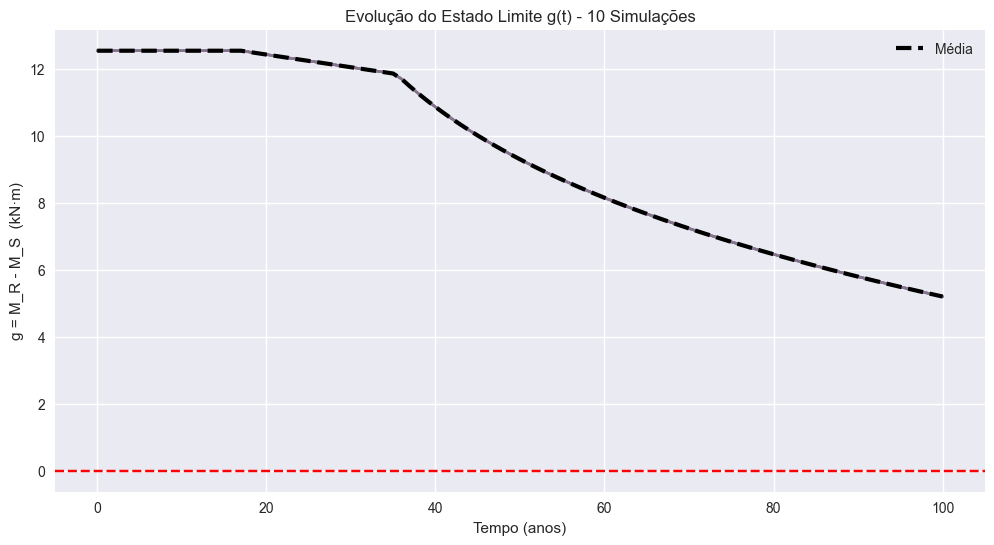

In [10]:
plt.figure(figsize=(12,6))
plt.plot(df_out, alpha=0.5)
plt.plot(times, df_out.mean(axis=1), 'k--', linewidth=3, label='Média')
plt.axhline(0, color='red', linestyle='--')
plt.title("Evolução do Estado Limite g(t) - 10 Simulações")
plt.xlabel("Tempo (anos)")
plt.ylabel("g = M_R - M_S  (kN·m)")
plt.grid(True)
plt.legend()
plt.show()

A conta é essa aqui:

$$y = k \cdot \sqrt{t}$$
$$k = \frac{y}{\sqrt{t}}$$